In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.metrics.pairwise import cosine_similarity
import json, warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


/tmp/ipykernel_7061/1846793969.py:5: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses
/tmp/ipykernel_7061/1846793969.py:6: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator


In [3]:
# Load the cleaned ATS pairs dataset
df = pd.read_csv('cleaned_resumeJD_pairs.csv')
print(f'Loaded: {len(df)} pairs')
print(f'\nLabel distribution:')
print(df['match_label'].value_counts())
print(f'\nScore range: {df["match_score"].min():.2f} – {df["match_score"].max():.2f}')
df.head(3)


Loaded: 500 pairs

Label distribution:
match_label
no match         190
match            158
partial match    152
Name: count, dtype: int64

Score range: 0.05 – 0.98


,resume_text,job_description,match_score,match_label,match_label_lower,resume_len,jd_len
0,CA/MBA with 5+ years in Valuation and Equity R...,We are looking for a passionate FP&A Analyst t...,0.55,partial match,partial match,160,145
1,Data scientist with 8 years applying B2B Sales...,We are looking for a passionate Design Lead to...,0.27,no match,no match,179,149
2,Performance marketer with 8 years scaling user...,We are looking for a passionate Security Analy...,0.46,partial match,partial match,168,140


In [4]:
#Train / Val / Test Split
#Stratify by match_label so each split has balanced high/medium/low

train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['match_label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['match_label']
)

print(f'Train:      {len(train_df)} pairs')
print(f'Validation: {len(val_df)} pairs')
print(f'Test:       {len(test_df)} pairs')
print()

# Verify each split has all 3 labels
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name} label dist: {split["match_label"].value_counts().to_dict()}')


Train:      350 pairs
Validation: 75 pairs
Test:       75 pairs

Train label dist: {'no match': 133, 'match': 111, 'partial match': 106}
Val label dist: {'no match': 29, 'match': 23, 'partial match': 23}
Test label dist: {'no match': 28, 'match': 24, 'partial match': 23}


In [5]:
#Convert to InputExample format — sentence-transformers expects this
#text1 = resume, text2 = job description, label = match_score (float 0-1)

train_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in train_df.iterrows()
]

val_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in val_df.iterrows()
]

print(f'Train examples: {len(train_examples)}')
print(f'Val examples:   {len(val_examples)}')
print(f'\nSample InputExample:')
print(f'  text1 (resume): {train_examples[0].texts[0][:80]}...')
print(f'  text2 (JD):     {train_examples[0].texts[1][:80]}...')
print(f'  label:          {train_examples[0].label}')


Train examples: 350
Val examples:   75

Sample InputExample:
  text1 (resume): CA/MBA with 7+ years in CA and M&A at Microsoft. Managed portfolios worth ₹44Cr....
  text2 (JD):     We are looking for a passionate Financial Analyst to join our Finance team at Ph...
  label:          0.7


In [6]:
#Base Model Baseline
print('Loading base BERT model...')
base_model = SentenceTransformer('all-mpnet-base-v2')
print('Loaded.')


Loading base BERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded.


In [7]:
# Evaluate base model on test set BEFORE fine-tuning
# This is our baseline, fine-tuning should beat this
print('Evaluating base model on test set...')

base_preds = []
for _, row in test_df.iterrows():
    emb1 = base_model.encode(row['resume_text'])
    emb2 = base_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    base_preds.append(float(sim))

base_mae  = mean_absolute_error(test_df['match_score'], base_preds)
base_rmse = np.sqrt(mean_squared_error(test_df['match_score'], base_preds))

print(f'\nBase Model — Test Set Performance')
print(f'  MAE:  {base_mae:.4f}')
print(f'  RMSE: {base_rmse:.4f}')
print()
print('Goal: fine-tuning should reduce MAE below this number.')

Evaluating base model on test set...

Base Model — Test Set Performance
  MAE:  0.2009
  RMSE: 0.2343

Goal: fine-tuning should reduce MAE below this number.


In [8]:
#Fine-Tune BERT

# Fresh model instance for fine-tuning (don't reuse base_model)
model = SentenceTransformer('all-mpnet-base-v2')

# DataLoader, shuffles training data each epoch
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# CosineSimilarityLoss: trains the model so that
# cosine_similarity(embed(resume), embed(jd)) ≈ match_score
train_loss = losses.CosineSimilarityLoss(model)

# Evaluator runs on val set after each evaluation_steps
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples, name='ats-val'
)

print('Training setup ready.')
print(f'  Batch size:   16')
print(f'  Train pairs:  {len(train_examples)}')
print(f'  Steps/epoch:  {len(train_dataloader)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Training setup ready.
  Batch size:   16
  Train pairs:  350
  Steps/epoch:  22


In [9]:
# Fine-tune
# epochs=15 is reasonable for 300-350 training pairs
# warmup_steps = 10% of total steps

total_steps   = len(train_dataloader) * 10
warmup_steps  = int(total_steps * 0.1)

print(f'Total steps:  {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'\nStarting fine-tuning...\n')

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=15,
    evaluation_steps=len(train_dataloader),   # evaluate once per epoch
    warmup_steps=warmup_steps,
    output_path='models/finetuned-bert',
    save_best_model=True,
    show_progress_bar=True
)

print('\nFine-tuning complete!')

Total steps:  220
Warmup steps: 22

Starting fine-tuning...



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Ats-val Pearson Cosine,Ats-val Spearman Cosine
22,No log,No log,0.768271,0.709551
44,No log,No log,0.804632,0.742817
66,No log,No log,0.796989,0.721844
88,No log,No log,0.805321,0.733853
110,No log,No log,0.796126,0.738633
132,No log,No log,0.795208,0.738306
154,No log,No log,0.787258,0.735987
176,No log,No log,0.786313,0.737339
198,No log,No log,0.791835,0.742205
220,No log,No log,0.788250,0.739942


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning complete!


In [10]:
#Evaluate Fine-Tuned Model

finetuned_model = SentenceTransformer('models/finetuned-bert')
print('Fine-tuned model loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [11]:
ft_preds = []
for _, row in test_df.iterrows():
    emb1 = finetuned_model.encode(row['resume_text'])
    emb2 = finetuned_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    ft_preds.append(float(sim))

ft_mae  = mean_absolute_error(test_df['match_score'], ft_preds)
ft_rmse = np.sqrt(mean_squared_error(test_df['match_score'], ft_preds))

print(f'\nFine-tuned Model — Test Set Performance')
print(f'  MAE:  {ft_mae:.4f}')
print(f'  RMSE: {ft_rmse:.4f}')


Fine-tuned Model — Test Set Performance
  MAE:  0.1574
  RMSE: 0.2015


In [12]:
# Side-by-side comparison
print('=' * 50)
print('MODEL COMPARISON')
print('=' * 50)
print(f'  Base MAE:         {base_mae:.4f}')
print(f'  Fine-tuned MAE:   {ft_mae:.4f}')
print(f'  Improvement:      {(base_mae - ft_mae)/base_mae*100:.1f}%')
print('=' * 50)

MODEL COMPARISON
  Base MAE:         0.2009
  Fine-tuned MAE:   0.1574
  Improvement:      21.7%


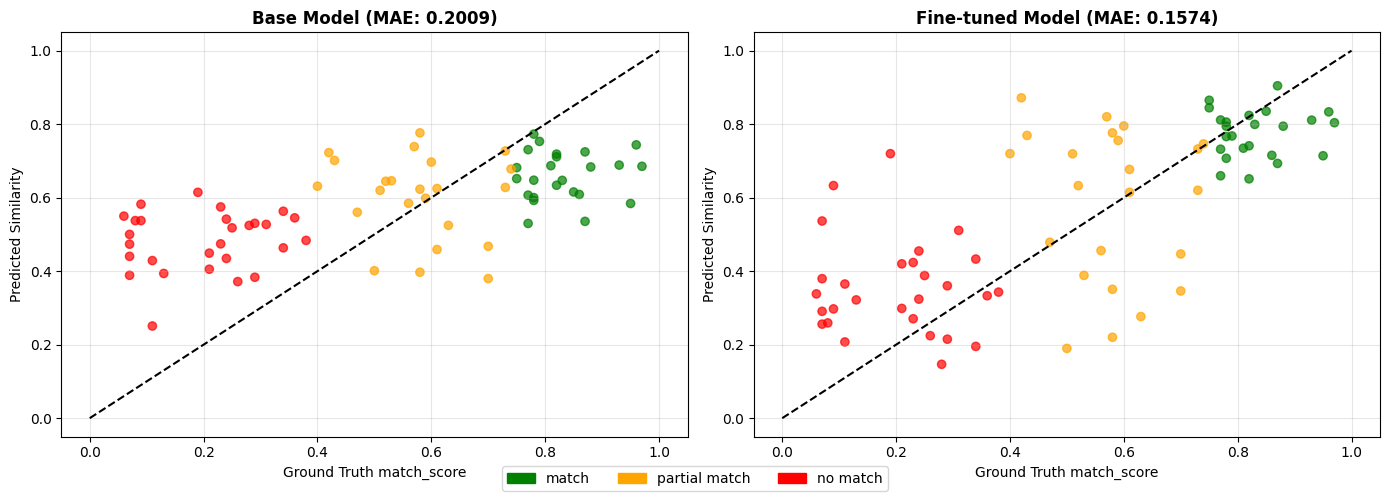

In [14]:
# Scatter plots: base vs fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = test_df['match_label'].map({'no match':'red','partial match':'orange','match':'green'})

for ax, preds, title, mae in [
    (axes[0], base_preds, 'Base Model', base_mae),
    (axes[1], ft_preds,   'Fine-tuned Model', ft_mae),
]:
    ax.scatter(test_df['match_score'], preds, c=colors, alpha=0.7)
    ax.plot([0,1],[0,1],'k--', label='Perfect')
    ax.set_xlabel('Ground Truth match_score')
    ax.set_ylabel('Predicted Similarity')
    ax.set_title(f'{title} (MAE: {mae:.4f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color='green', label='match'),
    Patch(color='orange', label='partial match'),
    Patch(color='red', label='no match'),
], loc='lower center', ncol=3)
plt.tight_layout()
plt.show()

In [15]:
metadata = {
    'base_model':       'all-mpnet-base-v2',
    'dataset':          'merged_dataset_clean.csv',
    'total_pairs':      len(df),
    'train_pairs':      len(train_df),
    'val_pairs':        len(val_df),
    'test_pairs':       len(test_df),
    'epochs':           15,
    'batch_size':       16,
    'base_mae':         round(float(base_mae), 4),
    'finetuned_mae':    round(float(ft_mae), 4),
    'improvement_pct':  round((base_mae - ft_mae) / base_mae * 100, 2),
}

with open('models/finetuned-bert/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: models/finetuned-bert/')
print(json.dumps(metadata, indent=2))

Saved: models/finetuned-bert/
{
  "base_model": "all-mpnet-base-v2",
  "dataset": "merged_dataset_clean.csv",
  "total_pairs": 500,
  "train_pairs": 350,
  "val_pairs": 75,
  "test_pairs": 75,
  "epochs": 15,
  "batch_size": 16,
  "base_mae": 0.2009,
  "finetuned_mae": 0.1574,
  "improvement_pct": 21.67
}


In [16]:
#Production Pipeline Test

def score_resume_against_jd(resume_text, jd_text, model):

    emb_resume = model.encode(resume_text, convert_to_numpy=True)
    emb_jd     = model.encode(jd_text,     convert_to_numpy=True)
    score      = cosine_similarity([emb_resume], [emb_jd])[0][0]
    return float(score)


# Test with realistic cases
test_cases = [
    {
        'label':  'HIGH match expected',
        'resume': 'Senior Python developer with 6 years experience. Built REST APIs using FastAPI and Django. Proficient in PostgreSQL, Docker, and AWS deployment.',
        'jd':     'We need a Python backend engineer with FastAPI or Django experience. Must know SQL databases and cloud deployment.',
    },
    {
        'label':  'MEDIUM match expected',
        'resume': 'Frontend developer with 3 years React and TypeScript experience. Some Node.js and Express for small APIs.',
        'jd':     'Full stack engineer needed. React frontend required, strong Python backend preferred. 4+ years experience.',
    },
    {
        'label':  'LOW match expected',
        'resume': 'Executive Chef with 12 years experience in fine dining. Expert in French cuisine, menu planning, and kitchen management.',
        'jd':     'Data Scientist with Python, machine learning, and SQL experience required.',
    },
]

print('Production Pipeline Test')
print('=' * 60)
for case in test_cases:
    score = score_resume_against_jd(case['resume'], case['jd'], finetuned_model)
    label = 'HIGH' if score > 0.70 else 'MEDIUM' if score > 0.45 else 'LOW'
    print(f"\n{case['label']}")
    print(f"  Predicted score: {score:.4f}  →  {label}")


Production Pipeline Test

HIGH match expected
  Predicted score: 0.7824  →  HIGH

MEDIUM match expected
  Predicted score: 0.7397  →  HIGH

LOW match expected
  Predicted score: 0.2572  →  LOW


In [17]:
# 1. Compress the entire finetuned-bert folder into a single zip file
!zip -r finetuned_bert_model.zip ./models/finetuned-bert

# 2. Trigger an automatic download of the zip file
from google.colab import files
files.download('finetuned_bert_model.zip')

  adding: models/finetuned-bert/ (stored 0%)
  adding: models/finetuned-bert/sentence_bert_config.json (deflated 43%)
  adding: models/finetuned-bert/model.safetensors (deflated 8%)
  adding: models/finetuned-bert/modules.json (deflated 64%)
  adding: models/finetuned-bert/config.json (deflated 48%)
  adding: models/finetuned-bert/tokenizer_config.json (deflated 53%)
  adding: models/finetuned-bert/config_sentence_transformers.json (deflated 40%)
  adding: models/finetuned-bert/README.md (deflated 74%)
  adding: models/finetuned-bert/tokenizer.json (deflated 71%)
  adding: models/finetuned-bert/eval/ (stored 0%)
  adding: models/finetuned-bert/eval/similarity_evaluation_ats-val_results.csv (deflated 48%)
  adding: models/finetuned-bert/metadata.json (deflated 41%)
  adding: models/finetuned-bert/2_Normalize/ (stored 0%)
  adding: models/finetuned-bert/1_Pooling/ (stored 0%)
  adding: models/finetuned-bert/1_Pooling/config.json (deflated 17%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>